# Fault-tolerant Bell-state preparation

A small Stim circuit describes the desired logical CSS state. Each Stim qubit is one encoded block of the selected `[[n, 1, d]]` CSS code.

In [1]:
import numpy as np
import stim


from spidercss.css_state import encoded_css_stabilizers, prepare_css_state
from spidercss.utils import count_operations, load_qecc


bell_state = stim.Circuit("""
    M 0
    MX 1
    CX 1 0
""")
ts = stim.TableauSimulator()
ts.do(bell_state)
print(ts.canonical_stabilizers())

[stim.PauliString("-XX"), stim.PauliString("+ZZ")]


Here `M` and `MX` are declarative preparation instructions for the `+1` logical `|0>` and `|+>` states; their stochastic Stim measurement results are not copied into the compiled circuit. `R` and `RX` are equivalent deterministic spellings. Other gates are rejected.

For `m` logical blocks, the physical X stabilizers consist of the block-local rows $I_m \otimes H_X$ and the encoded logical-state rows $S_X \otimes L_X$. The Z stabilizers are constructed in the same way. With `strategy="global"`, `prepare_css_state` passes one of these complete matrices to `cat_at_origin`, so the state is synthesized jointly. With `strategy="local"`, it instead prepares each block separately and implements logical CNOTs transversally.

In [2]:
# Explicitly postselecting the +1 outcomes shows the intended logical state.
logical_simulator = stim.TableauSimulator()
logical_simulator.set_num_qubits(2)
logical_simulator.postselect_z(0, desired_value=False)
logical_simulator.postselect_x(1, desired_value=False)
logical_simulator.cnot(1, 0)
print(logical_simulator.canonical_stabilizers())

[stim.PauliString("+XX"), stim.PauliString("+ZZ")]


In [3]:
def prepare_and_verify_bell_state(
    code, *, strategy="global", method="FAO", shots=256
):
    encoded_h_x, encoded_h_z = encoded_css_stabilizers(
        bell_state, code, method=method
    )
    assert not np.any(encoded_h_x @ encoded_h_z.T % 2)

    circuit = prepare_css_state(
        bell_state,
        code,
        method=method,
        max_basis_tries=1_000,
        strategy=strategy,
    )

    _, h_x, h_z, l_x, l_z, _ = load_qecc(code, method)
    n = h_x.shape[1]

    # Z samples check each block's Z stabilizers and the logical ZZ Bell stabilizer.
    # X samples similarly check the X stabilizers and logical XX.
    for basis, stabilizers, logical_operator in (
        ("Z", h_z, l_z),
        ("X", h_x, l_x),
    ):
        measured = circuit.copy()
        measured.append("M" + basis, range(2 * n))
        samples = measured.compile_sampler().sample(shots)[:, -2 * n:]
        samples = samples.reshape(shots, 2, n)

        assert not np.any(samples @ stabilizers.T % 2)
        logical_values = samples @ logical_operator.T % 2
        assert not np.any(logical_values[:, 0] ^ logical_values[:, 1])

    num_cnots, _ = count_operations(circuit)
    print(
        f"{code}: lifted stabilizers {encoded_h_x.shape} X / "
        f"{encoded_h_z.shape} Z; {2 * n} data qubits, "
        f"{circuit.num_qubits - 2 * n} preparation ancillas, "
        f"{num_cnots} CNOTs; Bell checks passed"
    )
    return circuit

## `[[7, 1, 3]]` code

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


7_1_3: lifted stabilizers (7, 14) X / (7, 14) Z; 14 data qubits, 6 preparation ancillas, 37 CNOTs; Bell checks passed


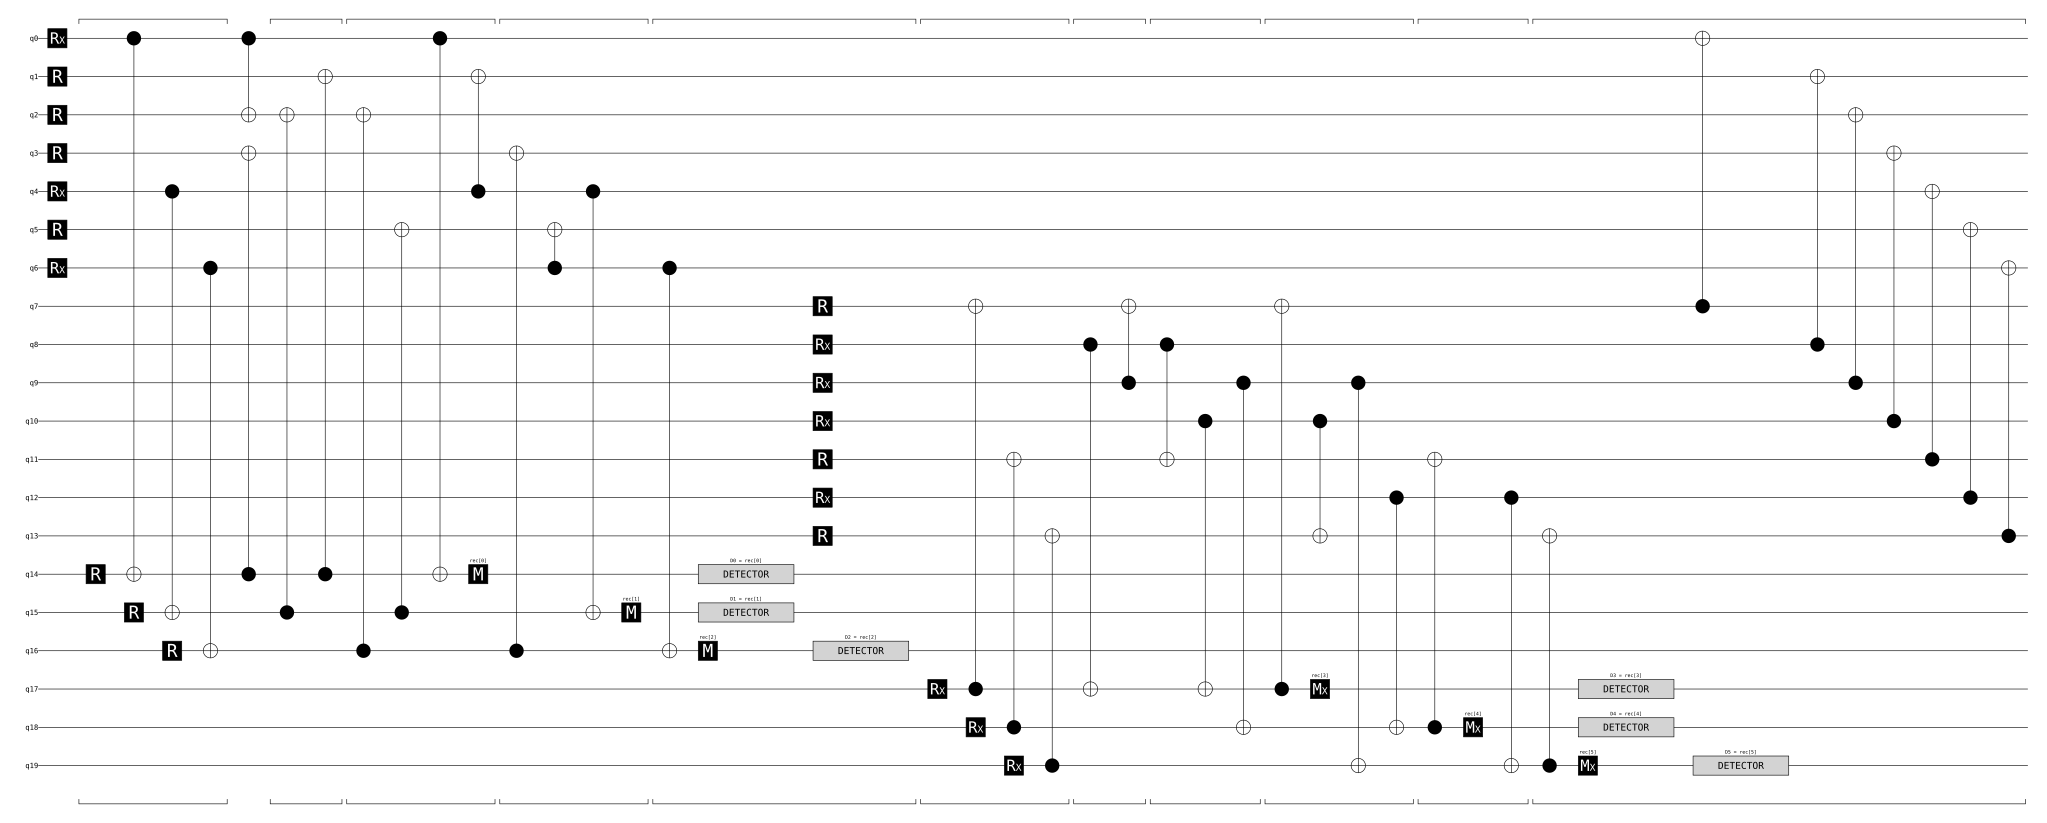

In [4]:
bell_7_1_3_local = prepare_and_verify_bell_state("7_1_3", strategy="local")
bell_7_1_3_local.diagram('timeline-svg')

7_1_3: lifted stabilizers (7, 14) X / (7, 14) Z; 14 data qubits, 14 preparation ancillas, 55 CNOTs; Bell checks passed


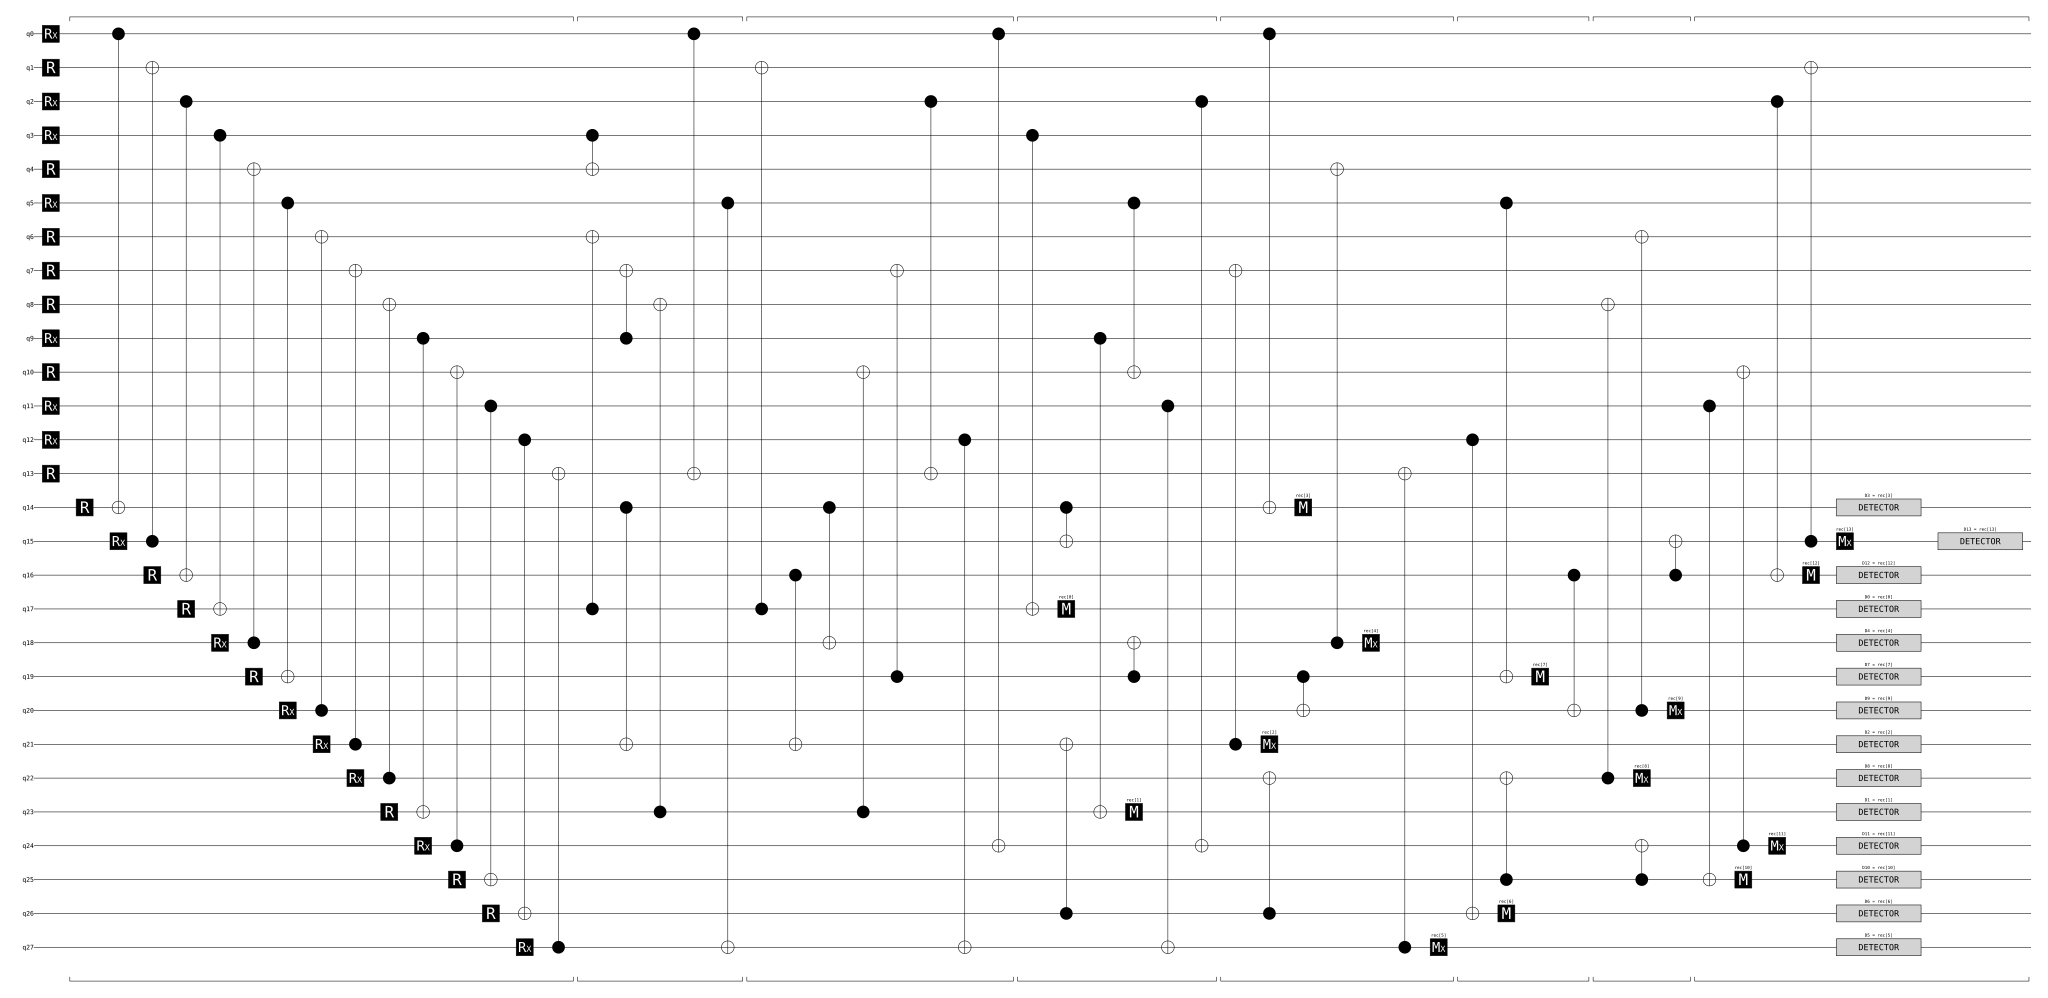

In [5]:
bell_7_1_3 = prepare_and_verify_bell_state("7_1_3", strategy="global")
bell_7_1_3.diagram('timeline-svg')

## `[[17, 1, 5]]` code

17_1_5: lifted stabilizers (17, 34) X / (17, 34) Z; 34 data qubits, 42 preparation ancillas, 165 CNOTs; Bell checks passed


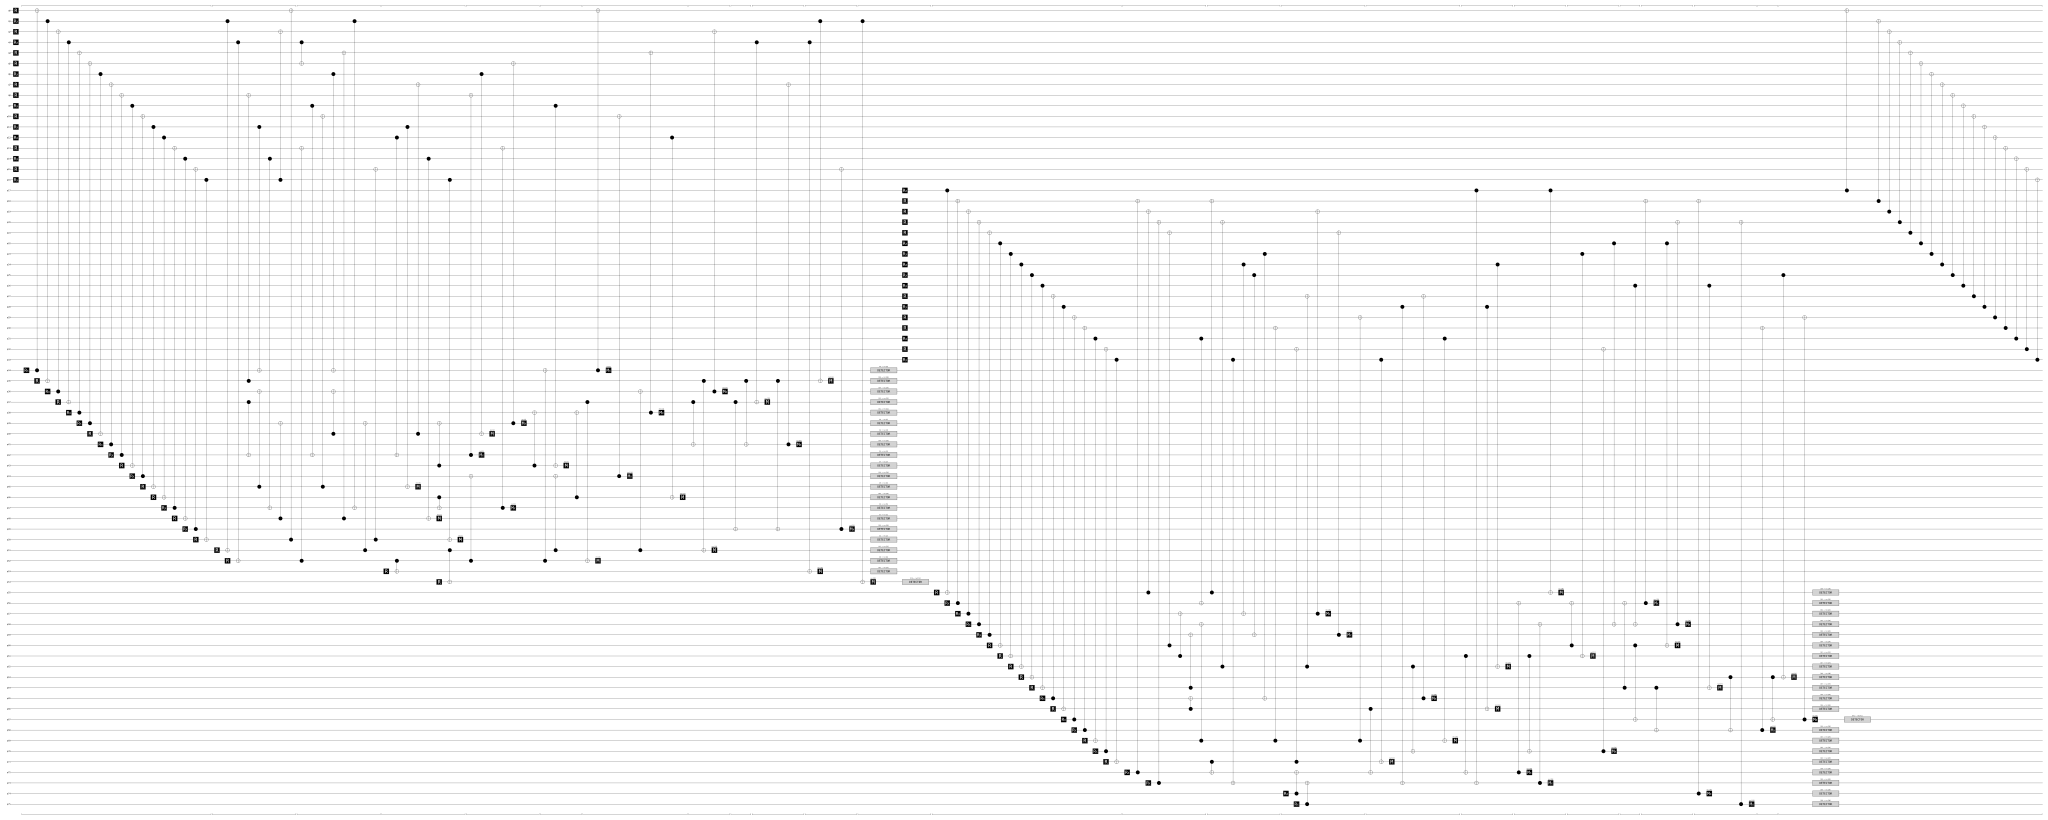

In [7]:
bell_17_1_5_local = prepare_and_verify_bell_state("17_1_5", strategy="local")
bell_17_1_5_local.diagram('timeline-svg')

17_1_5: lifted stabilizers (17, 34) X / (17, 34) Z; 34 data qubits, 62 preparation ancillas, 213 CNOTs; Bell checks passed


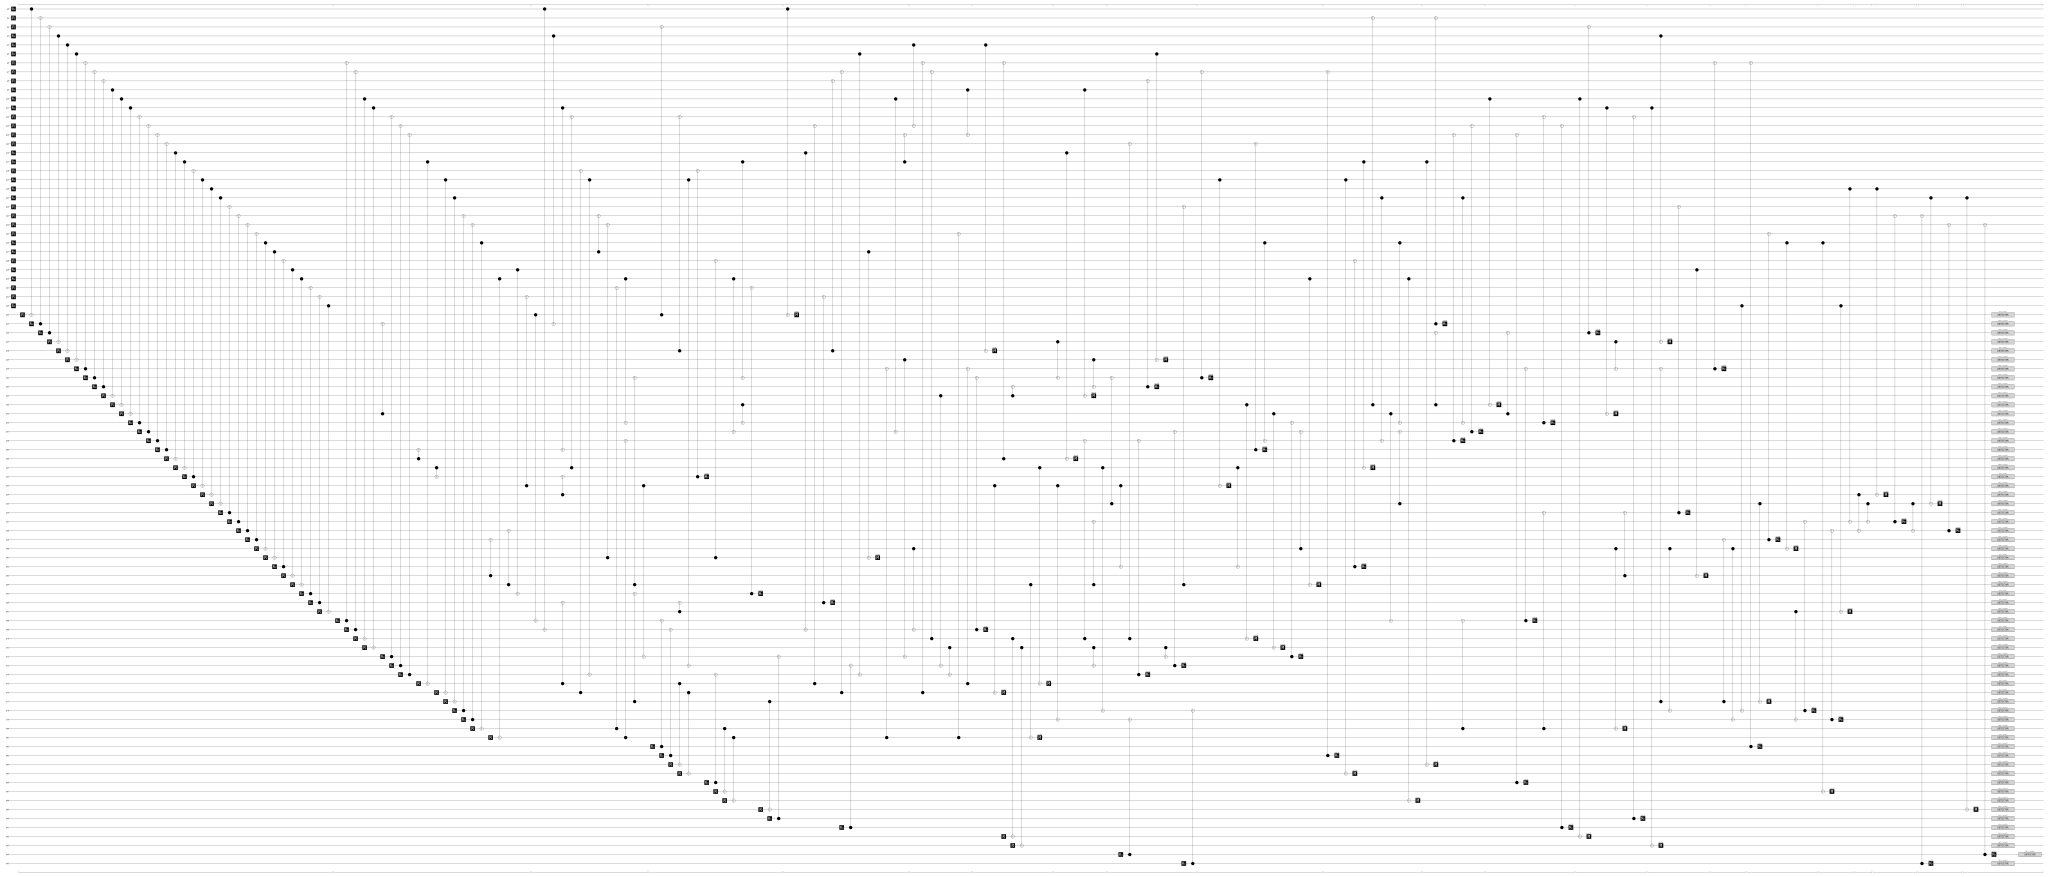

In [9]:
bell_17_1_5 = prepare_and_verify_bell_state("17_1_5", strategy="global")
bell_17_1_5.diagram('timeline-svg')